# **Manga-Anime Analysis**

Phoenix Robertson | PHY/MAT 231 | Spring 2026

# **Project Background**

For my final project I have decided to analyze data scraped from MyAnimeList.net, a website where fans of anime (Japanese animation) and manga (Japanese comics/graphic novels) are able to rank and discuss their favorite anime and manga. 

My main data set for this project details the top 500 manga, ranked based on user scores, on MyAnimeList.net. This data set was found on Kaggle and was updated 6 years ago. While having slightly older data might not seem as useful, I also aim to look at the turnover rate of the top 500 manga to the top 500 anime on MyAnimeList.net. Many anime began as manga and once they received enough positive fan attention, they are bought by a production company to become an anime. My secondary data set showcases the top 500 anime on MyAnimeList.net and was last updated in March of 2026. Having there be a time gap of several years between the two data sets will allow me to account for the time that the production of a series can take. The column headers from my manga data include 'Manga ID' (a numeric value given to each manga), 'Manga URL' (a link to the manga's page on MyAnimeList.net), 'English Title', 'Synonims Titles', 'Japanese Title', 'Type' (distinguishes if the media is a novel, manga, or manhwa, a Korean comic, since the site has grown to serve a wider fanbase), 'Volumes', 'Chapters', 'Status' (if the series is finished), 'Published', 'Published Dates', 'Genres', 'Author', 'Serialization', 'Score', 'Ranked', 'Popularity', 'Members' (how many users included the manga in their list of manga), 'Favorites' (how many users selected the manga as a favorite), and 'Score Voted By' (a metric to show how many users voted on the score of the manga). I also added the column FP which stands for favorited-percentage. This is a measure taken by computing favorites/score_voted_by * 100 to show what percentage of users that voted for the manga also favorited it. The anime data set includes column headers such as 'mal_id' (an identification number for the anime in the MyAnimeList.net system), 'title_english', 'type' (TV, movie, or special episode), 'source' (if the anime is an original concept or based on a book), 'episodes', 'status' (currently airing or not), 'airing' (a true or flase statement to denote if the series is still airing), 'rating' (a TV rating such as G, PG, or PG-13), 'score', 'scored_by', 'rank', 'popularity' (a ranking of popularity based on how many users added the anime to their list), 'members' (members that added the anime to their list), 'favorites' (members that favorited the anime), 'year' (year of release), 'genres', and 'studios' (a list of all studios that animated the series.

Manga Data on Kaggle: https://www.kaggle.com/datasets/ajpass/top-ranked-mangas-myanimelist-mal 

Anime Data on Kaggle: https://www.kaggle.com/datasets/muhammadaqeelkabir/top-anime-csv

I decided to take on this project because I am a fan of both manga and anime and have been recently reminded of the social popularity scope of anime and manga with the release of recent anime series sending waves across both social media and my personal social life. I am impressed by the scope of anime and manga, especially so in recent years, as it has gone from being considered a social taboo to a socially acceptable interest. I am excited to undertake this project and examine data that is the accumulation of discussion from years of anime and manga fans.

# **Research Questions**

Q1 - Who are the powerhouses of serialization in the manga industry? (Think a production house, which companies have the most of their manga ranking in the top 500?)

Q2 - Does production status (currently publishing, finished, or on hiatus) have any correlation to popularity score? (Does a manga that has finished have a higher popularity score than a manga that is still being released?)

Q3 - Is there overlap between the top 500 manga and the top 500 anime on MyAnimeList.net? If so, how many of the top 500 anime were based on anime that were in the top 500 manga list?

# **Setup**

## Importing Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

## Loading the Data

In [3]:
# Load CSV for manga
df = pd.read_csv('mangatruefinal.csv')

# Load into SQLite
con = sqlite3.connect(':memory:')
df.to_sql('manga', con, index=False)
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
df.head()

Rows: 500, Columns: 22


,Manga_ID,Manga_URL,English_Title,Synonims_Titles,Japanese_Title,Type,Volumes,Chapters,Status,Published,...,Author,Serialization,Score,Ranked,Popularity,Members,Favorites,Score_Voted_By,title_english,Fp
0,1.0,https://myanimelist.net/manga/1/Monster,Monster,Unknown,MONSTER,Manga,18,162,Finished,"Dec 5, 1994 to Dec 20, 2001",...,"['Urasawa, Naoki (Story & Art)']",Big Comic Original,9.07,5.0,39.0,103030.0,10000.0,41412.0,Monster,24.14759007
1,2.0,https://myanimelist.net/manga/2/Berserk,Berserk,Berserk: The Prototype,ベルセルク,Manga,Unknown,Unknown,Publishing,"Aug 25, 1989 to ?",...,"['Miura, Kentarou (Story & Art)']",Young Animal,9.33,1.0,4.0,296958.0,61992.0,139571.0,Berserk,44.41610363
2,3.0,https://myanimelist.net/manga/3/20th_Century_Boys,20th Century Boys,"20 Seiki Shounen, Nijuu Seiki Shounen, Nijuuss...",20世紀少年,Manga,22,249,Finished,"Sep 27, 1999 to Apr 24, 2006",...,"['Urasawa, Naoki (Story & Art)']",Big Comic Spirits,8.96,11.0,37.0,104666.0,10822.0,40663.0,20th Century Boys,26.61387502
3,4.0,https://myanimelist.net/manga/4/Yokohama_Kaida...,Unknown,"Yokohama Shopping Log, Yokohama Shopping Trip,...",ヨコハマ買い出し紀行,Manga,14,142,Finished,"Apr 25, 1994 to Feb 25, 2006",...,"['Ashinano, Hitoshi (Story & Art)']",Afternoon,8.73,35.0,206.0,39806.0,3448.0,11067.0,Unknown,31.15568808
4,7.0,https://myanimelist.net/manga/7/Hajime_no_Ippo,Unknown,"The Fighting!, Fighting Spirit, The Fighting! ...",はじめの一歩,Manga,Unknown,Unknown,Publishing,"Sep 27, 1989 to ?",...,"['Morikawa, George (Story & Art)']",Shounen Magazine (Weekly),8.68,48.0,158.0,48463.0,4707.0,22862.0,Unknown,20.58874989


In [4]:
# Load CSV for anime
df2 = pd.read_csv('animedatatrue1.csv')

# Load into SQLite
conn = sqlite3.connect(':memory:')
df2.to_sql('anime3', con, index=False)
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
df2.head()

Rows: 500, Columns: 22


,mal_id,title_english,type,source,episodes,status,airing,rating,score,scored_by,rank,popularity,members,favorites,year,genres,studios
0,1,Cowboy Bebop,TV,Original,26.0,Finished Airing,False,R - 17+ (violence & profanity),8.75,1052474,47.0,42,2037770,89098,1998.0,"Action, Award Winning, Sci-Fi",Sunrise
1,5,Cowboy Bebop: The Movie,Movie,Original,1.0,Finished Airing,False,R - 17+ (violence & profanity),8.38,230687,241.0,654,408768,1773,NaN,"Action, Sci-Fi",Bones
2,6,Trigun,TV,Manga,26.0,Finished Airing,False,PG-13 - Teens 13 or older,8.22,398767,407.0,264,827447,17494,1998.0,"Action, Adventure, Sci-Fi",Madhouse
3,18,Initial D Fourth Stage,TV,Manga,24.0,Finished Airing,False,PG-13 - Teens 13 or older,8.17,118322,466.0,1301,212751,1423,2004.0,"Action, Drama",A.C.G.T.
4,19,Monster,TV,Manga,74.0,Finished Airing,False,R+ - Mild Nudity,8.89,502743,25.0,119,1308032,61307,2004.0,"Drama, Mystery, Suspense",Madhouse


## Describing the Data

In [5]:
# Summary of statistics for manga
df.describe()

,Manga_ID,Score,Ranked,Popularity,Members,Favorites,Score_Voted_By
count,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000
mean,34167.068687,8.368788,250.781818,1044.006061,34228.822222,2770.620202,14740.525253
std,38702.637961,0.220287,145.051899,1365.037502,44514.530897,6152.665049,22877.626995
min,1.000000,8.110000,1.000000,1.000000,555.000000,14.000000,219.000000
25%,1195.500000,8.200000,125.000000,188.000000,8188.500000,297.500000,2495.000000
50%,16081.000000,8.320000,249.000000,560.000000,17589.000000,775.000000,6111.000000
75%,60668.000000,8.480000,376.500000,1379.000000,41878.500000,2698.500000,17031.000000
max,126287.000000,9.330000,500.000000,13941.000000,312183.000000,75106.000000,185560.000000


In [6]:
# Column types and missing values for manga
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Manga_ID         495 non-null    float64
 1   Manga_URL        495 non-null    object 
 2   English_Title    495 non-null    object 
 3   Synonims_Titles  495 non-null    object 
 4   Japanese_Title   495 non-null    object 
 5   Type             495 non-null    object 
 6   Volumes          495 non-null    object 
 7   Chapters         495 non-null    object 
 8   Status           495 non-null    object 
 9   Published        495 non-null    object 
 10  Published_Dates  495 non-null    object 
 11  Genres           495 non-null    object 
 12  Author           495 non-null    object 
 13  Serialization    407 non-null    object 
 14  Score            495 non-null    float64
 15  Ranked           495 non-null    float64
 16  Popularity       495 non-null    float64
 17  Members         

In [7]:
# Summary of statistics for anime
df2.describe()

,mal_id,episodes,score,scored_by,rank,popularity,members,favorites,year
count,500.000000,492.000000,500.000000,5.000000e+02,492.000000,500.000000,5.000000e+02,500.000000,297.000000
mean,30996.616000,18.357724,8.428940,3.271719e+05,246.552846,1559.430000,5.789175e+05,13815.252000,2015.070707
std,20276.672967,35.417988,0.222604,4.517006e+05,142.217810,1919.380637,6.924760e+05,29497.765969,9.007038
min,1.000000,1.000000,8.160000,9.190000e+02,1.000000,1.000000,2.212000e+03,24.000000,1970.000000
25%,10143.250000,1.000000,8.250000,4.857050e+04,123.750000,294.750000,1.133312e+05,852.000000,2010.000000
50%,35847.000000,12.000000,8.370000,1.519620e+05,246.500000,839.500000,3.296165e+05,3453.500000,2017.000000
75%,49393.500000,24.000000,8.562500,4.098580e+05,369.250000,2174.250000,7.721738e+05,13553.750000,2022.000000
max,63019.000000,500.000000,9.280000,3.038808e+06,494.000000,12270.000000,4.316356e+06,249284.000000,2026.000000


In [8]:
# Column types and missing for anime
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mal_id         500 non-null    int64  
 1   title_english  500 non-null    object 
 2   type           500 non-null    object 
 3   source         500 non-null    object 
 4   episodes       492 non-null    float64
 5   status         500 non-null    object 
 6   airing         500 non-null    bool   
 7   rating         500 non-null    object 
 8   score          500 non-null    float64
 9   scored_by      500 non-null    int64  
 10  rank           492 non-null    float64
 11  popularity     500 non-null    int64  
 12  members        500 non-null    int64  
 13  favorites      500 non-null    int64  
 14  year           297 non-null    float64
 15  genres         494 non-null    object 
 16  studios        498 non-null    object 
dtypes: bool(1), float64(4), int64(5), object(7)
memory usa

# **Data Cleaning**

## Identifying Issues

The largest issue that I faced while doing the initial part of this project was cleaning my data. The manga table contained a lot of unknown values listed for the titles of manga. This means that I have to refer to each manga by the unique, numeric id value given to it by the MyAnimeList.net website. I will be using the same system to refer to anime, but this will prove to be an issue because the id numbers for manga and the id numbers for anime, even if they are for the same story/for something by the same title, are different. I would like to brainstorm with the professor to decide how I will be able to get around this issue when it comes to cleaning my data and joining my anime and manga data sets. 

## Cleaning Steps

I had to clean the data for duplicate entries in Google Sheets. First, I did this by looking through the Google sheet with all of my data in it and looking at everything. After the first glance, I used a formatting command to do this that I researched on my own. 

I had to take an additional cleaning step to prepare to join my two data sets together. Through outside research I discovered that you can use SQL to join two data sets using the INNER JOIN command. In order to do this, both data sets must have a column with the same header, so I added a column with the header "title_english" to my manga data set to match my anime data set. 

In order to answer my second question, which works with the genres of manga, I had to undergo additional data cleaning. To be able to answer my question about if there is a relationship between production status and genre, I needed to be able to look at the genres of each manga. In the original manga data set I was given, the genres were all separated with brackets and commas so I had to manually remove these commas and put each genre in its own column. This motivated me to make my third csv file that I used in this project, 'genretable.csv'.

# **Exploratory Analysis**

Initial graphs and observations before diving into your specific questions.

In [9]:
# Exploratory plots here
resultexplore1 = pd.read_sql_query("""
    SELECT
        AVG(Score) AS avg_score
    FROM manga
""", con)

resultexplore1

,avg_score
0,8.368788


"Resultexplore1" demonstrates the average score of all manga from the manga data set.

In [10]:
resultexplore2= pd.read_sql_query("""
    SELECT
        MAX(Popularity) AS max_popularity
    FROM manga
""", con)

resultexplore2

,max_popularity
0,13941.0


"Resultexplore2" gives the maximum popularity value from the manga data set.

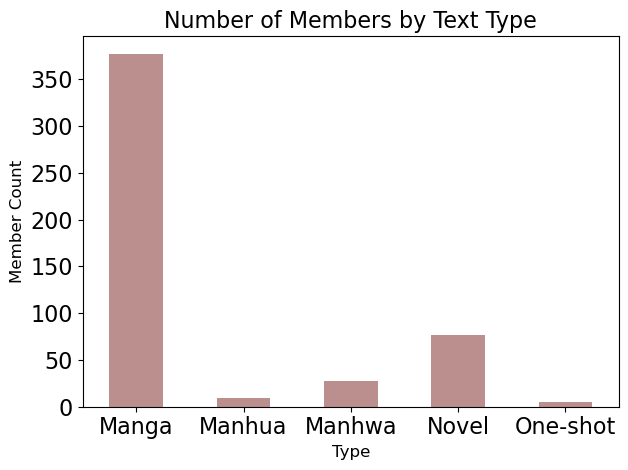

In [11]:
resultexplore3 = df.groupby('Type')['Members'].count()
resultexplore3.plot(kind = 'bar', color = 'rosybrown', fontsize = 16) 
plt.title('Number of Members by Text Type', fontsize=16)
plt.xlabel('Type', fontsize=12)
plt.ylabel('Member Count', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

"Resultexplore3" shows us that the type of text that has the highest amount of member interaction is manga. 

# **Question 1 (all parts)**

## Question 1

Who are the powerhouses of serialization in the manga industry? (Think a production house, which companies have the most of their manga ranking in the top 500?)

## Analysis

In [12]:
# Your analysis code here
result1 = df['Serialization'].value_counts().head(10)
print(result1)

Serialization
Shounen Jump (Weekly)        35
Shounen Magazine (Weekly)    20
Hana to Yume                 16
Shounen Sunday               15
Afternoon                    14
Naver Webtoon                14
GFantasy                     10
Young Jump                   10
LaLa                          9
Big Comic Spirits             9
Name: count, dtype: int64


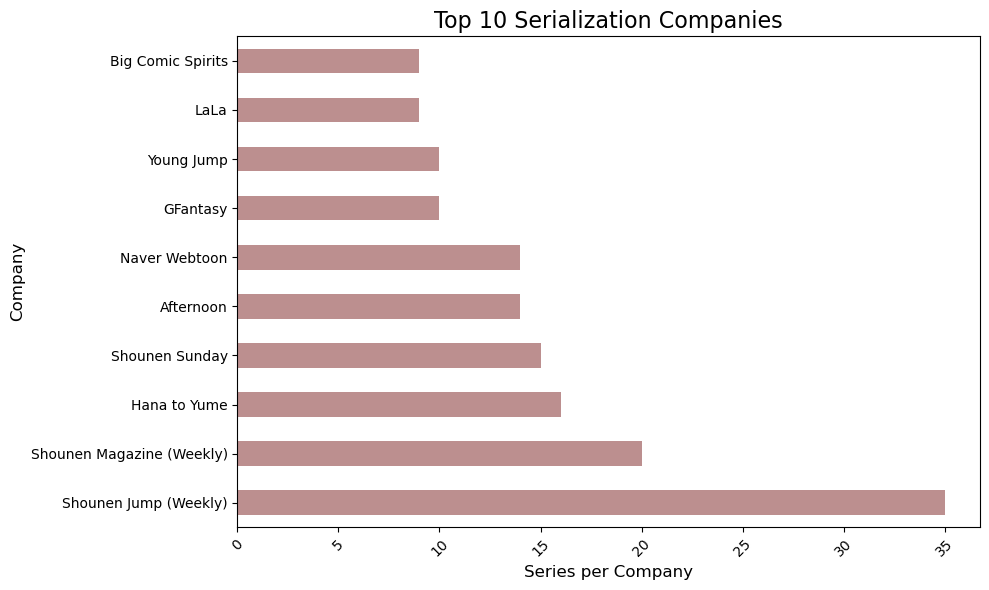

In [13]:
# Your visualization here
result1 = df['Serialization'].value_counts().head(10)
result1.plot(kind='barh', color='rosybrown', figsize=(10, 6))
plt.title('Top 10 Serialization Companies', fontsize=16)
plt.xlabel('Series per Company', fontsize=12) #change times use to books under the company
plt.ylabel('Company', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Findings

Based on the data, the top two serializaton companies are Shounen Jump (Weekly) and Shounen Magazine (Weekly). I did outside research to check to see if these are the same company and they are not, they just have similar names. This does however only tackle one side of what it means to be "powerhouse" (from the quantity standpoint), so I will create further plots to examine an alternate definition of what it means to be a powerhouse.

## Question 1.2

Being a powerhouse is not only about quantity, but also about quality. What is the distribution of average scores within the top 10 companies?

## Analysis

In [14]:
# Your analysis code here
result1b = pd.read_sql_query("""
    SELECT Serialization, AVG(Score) AS Average_Score FROM manga 
    WHERE Serialization IN ('Shounen Jump (Weekly)', 'GFantasy','Shounen Magazine (Weekly)', 'Hana to Yume', 'Shounen Sunday', 'Afternoon', 'Naver Webtoon', 'Young Jump', 'LaLa', 'Big Comic Spirits')
    GROUP BY Serialization
""", con)
result1b

,Serialization,Average_Score
0,Afternoon,8.443571
1,Big Comic Spirits,8.430000
2,GFantasy,8.379000
3,Hana to Yume,8.368750
4,LaLa,8.301111
5,Naver Webtoon,8.338571
6,Shounen Jump (Weekly),8.380000
7,Shounen Magazine (Weekly),8.367500
8,Shounen Sunday,8.308667
9,Young Jump,8.514000


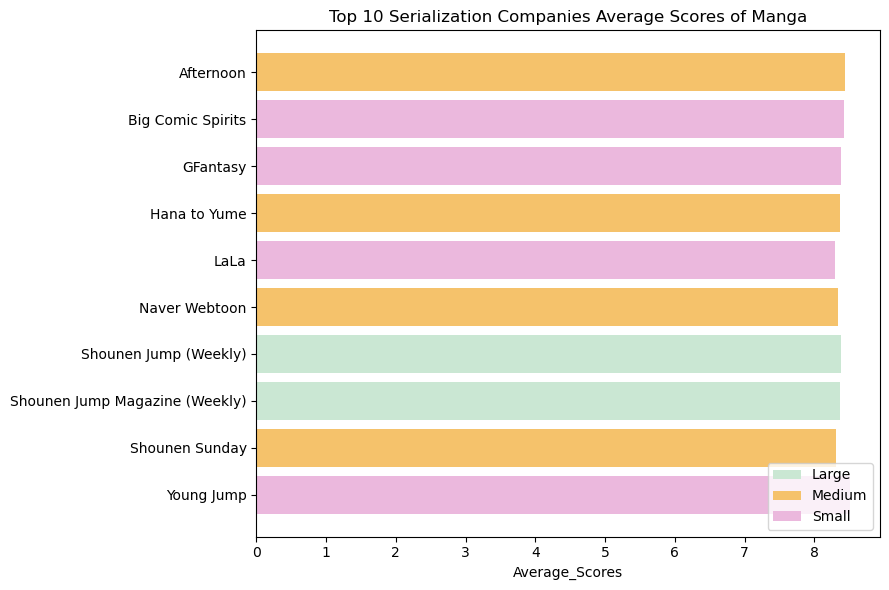

In [15]:
# Your visualization here

companies = ['Afternoon', 'Big Comic Spirits', 'GFantasy', 'Hana to Yume', 'LaLa',
            'Naver Webtoon', 'Shounen Jump (Weekly)', 'Shounen Jump Magazine (Weekly)', 'Shounen Sunday', 'Young Jump']
avg_score = [8.443571, 8.430000, 8.379000, 8.368750, 8.301111, 8.338571, 8.380000, 8.367500, 8.308667, 8.514000]
comp_size = ['Medium', 'Small', 'Small', 'Medium', 'Small', 'Medium', 'Large', 'Large', 'Medium', 'Small']

color_map = {'Large': '#CAE7D3', 'Medium': '#F5C26B',
             'Small': '#EBB8DD'}
colors = [color_map[c] for c in comp_size]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(companies[::-1], avg_score[::-1], color=colors[::-1])

ax.set_xlabel('Average_Scores')
ax.set_title('Top 10 Serialization Companies Average Scores of Manga')

# legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

## Findings

There is not a great deal of difference in the average scores of all the companies in the top 10 for most used serialization companies. Young Jump has a slightly higher average score than the other companies in the top 10. This leads us to believe that the companies that produce a large quantity of manga all have a similar quality in their manga. 

In order to make my grouped horizontal bar plot, I decided to define the size of each of the top 10 companies based on the number of manga they've serialized. I defined a large company has having serialized 20 or more manga, a medium company as having serialized 19-11 manga, and then 10 or less as a small company.

## Question 1.3

How many different volumes of manga has each serialization company published?

## Analysis

In [16]:
# Your analysis code here
result1c2 = pd.read_sql_query("""
    SELECT Serialization, AVG(Ranked) AS Rank, SUM(Volumes) AS Volumes, AVG(Fp) AS FP FROM manga 
    
    GROUP BY Serialization
    ORDER BY Rank ASC;
""", con)
result1c2

,Serialization,Rank,Volumes,FP
0,Mephisto,12.0,6.0,22.475647
1,Web Comic Gamma,16.0,0.0,24.241597
2,Animage,22.0,7.0,24.257382
3,Tonari no Young Jump,31.0,0.0,20.028974
4,Cookie,42.0,21.0,28.505575
...,...,...,...,...
137,Manga Time Kirara Carat,472.0,0.0,22.036728
138,Comic@Bunch,475.0,0.0,16.716147
139,Dengeki G's magazine,481.0,2.0,15.408805
140,Comic Blade Zebel,488.0,7.0,12.780364


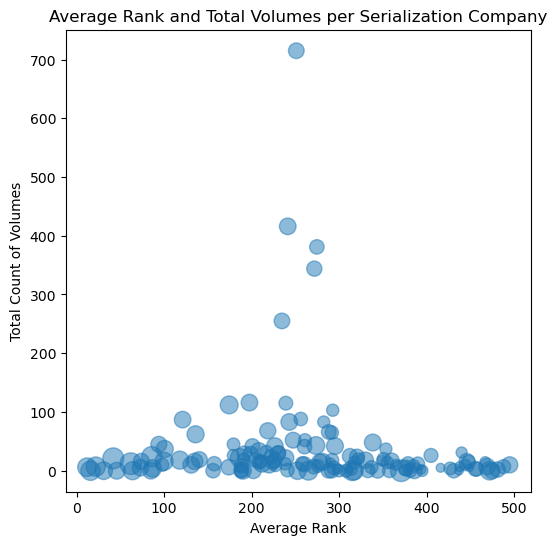

In [18]:
# Your visualization code here --> find out why this isnt working
df1c = pd.DataFrame(result1c2)
plt.figure(figsize=(6,6))
plt.scatter(result1c2['Rank'],result1c2['Volumes'],s=result1c2['FP']*8, alpha=0.5)
plt.xlabel('Average Rank')
plt.ylabel('Total Count of Volumes')
plt.title('Average Rank and Total Volumes per Serialization Company')
plt.show()

## Findings

Producing this bubble plot showed me that Shounen Jump (Weekly) does produce the top number of manga, however they were scoring in the middle area in terms of average rank. This means that while they may be a top producer of manga in terms of the quantity of manga they produce, they do not produce manga of the highest quality. An additional SQL table, made by result1c2, showed that the company with the highest average ranking was Mephisto. I have attempted to research Mephisto and haven't been able to find any information about them. It is my prediction that they are a relatively small company, since they have only released 6 volumes, thus they were able to prioritize quality over profits and a high volume release count.

To provide more clarity on my plot for question 1.3, the size of the bubbles was decided by a variable called "FP" which stands for "average favorite percentage." I found the value of favorite percentage by adding a column to my manga data table that was filled with the formula favorites/score_voted_by *100. This value determines the percentage of people that favorited the title out of the total number of people that voted on the score of the title. I then took the average of these scores within each company.

# **Question 2 (all parts)**

## Question 2.1

Does production status (currently publishing, finished, or on hiatus) have any correlation to popularity score? (Does a manga that has finished have a higher popularity score than a manga that is still being released?)

## Analysis

In [19]:
# Your analysis code here
result2 = pd.read_sql_query("""
    SELECT Status, AVG(Popularity) AS Average_Popularity, AVG(Ranked) AS Average_Rank, AVG(Favorites) AS Average_Favorites FROM manga 
    GROUP BY Status
    ORDER BY Average_Popularity DESC
""", con)
result2

,Status,Average_Popularity,Average_Rank,Average_Favorites
0,Publishing,1113.103448,227.524138,3685.151724
1,Finished,1022.841499,262.285303,2344.835735
2,On Hiatus,152.333333,44.333333,7817.333333
3,None,NaN,NaN,NaN


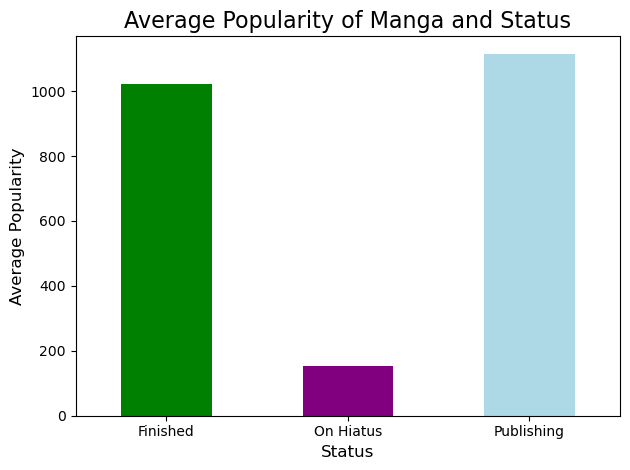

In [20]:
# Your visualization here
result2b = df.groupby('Status')['Popularity'].mean()
color = ['green', 'purple', 'lightblue']
result2b.plot.bar(color=color) 
plt.title('Average Popularity of Manga and Status', fontsize=16)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Average Popularity', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Findings

This data demonstrates that manga that are currently being published have a higher average popularity than other categories. I'm a bit surprised by this since I thought that the adoration people hold for older manga would pull the finished category to first place. I am not shocked that the on hiatus status was ranked below both the currently being published and the finished sections, since a pause in a story's release can lead to a decrease in popularity while audiences take time away from the story.

## Question 2.2

Do similarities exist in the manga that are finished, versus those on hiatus and those currently being published? What is the genre distribution in each category?

In [21]:
# Your analysis code here
con = sqlite3.connect(':memory:')
df3 = pd.read_csv('genretable.csv')
df3.to_sql('genretable', con, index=False)

genre_cols =['G1','G2','G3','G4','G5','G6','G7','G8','G9','G10','G11']
melted = df3.melt(id_vars=['English_Title', 'Status'], value_vars=genre_cols, value_name='Genre')
melted = melted.dropna(subset=['Genre'])
melted = melted[melted['Genre'] != '']

result2b2 = melted.groupby(['Genre','Status']).size()
result2b2 = result2b2.reset_index(name='Number_of_Manga')
result2b2 = result2b2.sort_values(by='Number_of_Manga', ascending=False)

result2b2

,Genre,Status,Number_of_Manga
64,Slice,Finished,130
62,Shounen,Finished,123
8,Drama,Finished,119
45,Romance,Finished,111
79,Action,Finished,108
...,...,...,...
92,Ecchi,Finished,1
99,Mecha,Publishing,1
97,Josei,Finished,1
112,Slice,Publishing,1


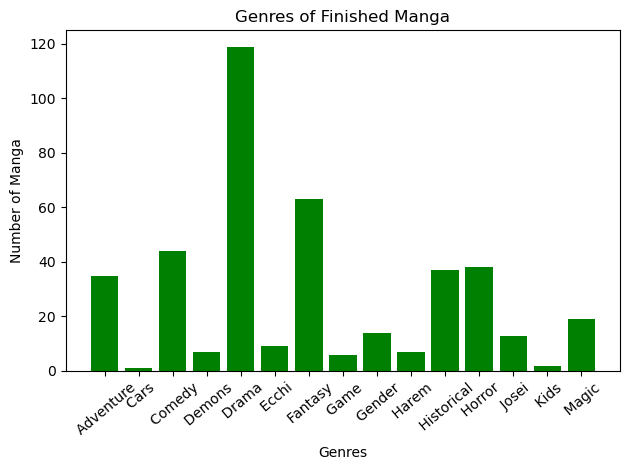

In [22]:
# Your visualization here
result2b2_finished = (melted[melted['Status'] == 'Finished'].groupby('Genre').size().reset_index(name='Number_of_Manga')).head(15)
result2b2_finished
plt.bar(result2b2_finished['Genre'],result2b2_finished['Number_of_Manga'], color = 'green')
plt.title('Genres of Finished Manga')
plt.xlabel('Genres')
plt.xticks(rotation=40)
plt.ylabel('Number of Manga')
plt.tight_layout()
plt.show()

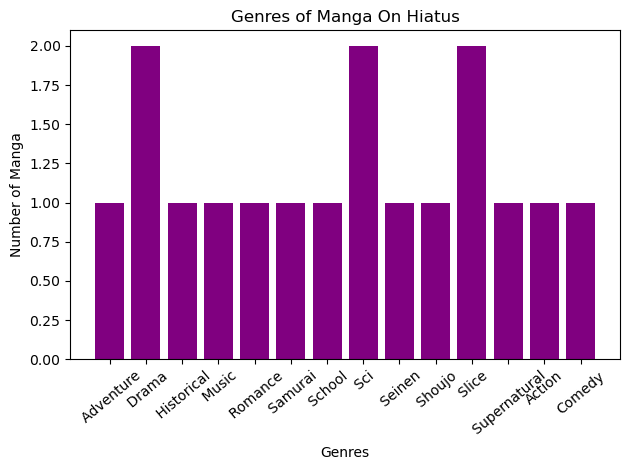

In [23]:
# Your visualization here
result2b2_h = (melted[melted['Status'] == 'On Hiatus'].groupby('Genre').size().reset_index(name='Number_of_Manga')).head(14)

plt.bar(result2b2_h['Genre'],result2b2_h['Number_of_Manga'], color = 'purple')
plt.title('Genres of Manga On Hiatus')
plt.xlabel('Genres')
plt.xticks(rotation=40)
plt.ylabel('Number of Manga')
plt.tight_layout()
plt.show()

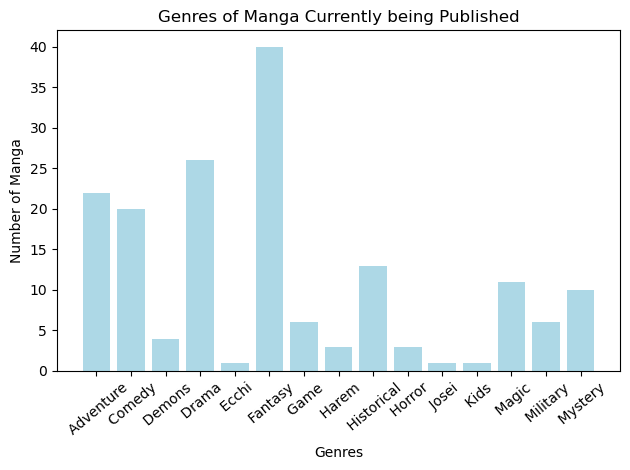

In [24]:
# Your visualization here
result2b2_publishing = (melted[melted['Status'] == 'Publishing'].groupby('Genre').size().reset_index(name='Number_of_Manga')).head(15)

plt.bar(result2b2_publishing['Genre'],result2b2_publishing['Number_of_Manga'],color = 'lightblue')
plt.title('Genres of Manga Currently being Published')
plt.xlabel('Genres')
plt.xticks(rotation=40)
plt.ylabel('Number of Manga')
plt.tight_layout()
plt.show()

In [25]:
# Your analysis code here
genre_cols =['G1','G2','G3','G4','G5','G6','G7','G8','G9','G10','G11']
melted = df3.melt(id_vars=['English_Title', 'Status'], value_vars=genre_cols, value_name='Genre')
melted = melted.dropna(subset=['Genre'])
melted = melted[melted['Genre'] != '']

result2b2a = melted.groupby(['Genre']).size()
result2b2a = result2b2a.reset_index(name='Number_of_Manga')
result2b2a = result2b2a.sort_values(by='Number_of_Manga', ascending=False)

result2b2a
#This data frame was made to check what the most popular manga genres are across production status

,Genre,Number_of_Manga
30,Slice,181
29,Shounen,168
38,Action,162
4,Drama,147
23,Romance,145
40,Comedy,121
26,Sci,121
34,Supernatural,117
25,School,115
27,Seinen,106


<Axes: title={'center': 'Counts of Manga by Genre and Status'}, xlabel='Status'>

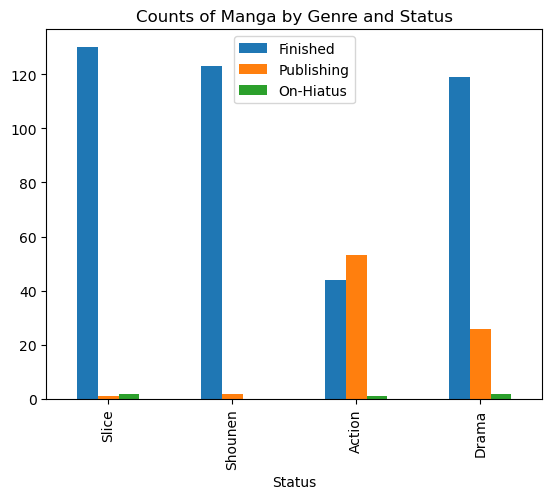

In [26]:
# Your visualization here
df5 = pd.DataFrame([['Slice', 130, 1, 2], ['Shounen', 123, 2, 0], ['Action', 44, 53, 1],['Drama', 119, 26, 2]],columns=['Status', 'Finished', 'Publishing', 'On-Hiatus'])
df5.plot(x='Status',kind='bar', title='Counts of Manga by Genre and Status')

## Findings

I was able to gather a lot of information from these three plots. I was able to learn that among the finished manga, the most common genre was drama, followed by fantasy, and comedy. Out of the manga that was on hiatus, the most common genres were drama, science, and slice of life. Out the manga that is currently being published, the most common genres were fantasy, adventure, and drama. Since the drama genre was repeated across all three production statuses, I think that the relationship between production status has less to do with genre and more to do with the general distribution of manga per genre. Drama is very popular genre, as was seen in my result2b2a which is a table that looks at the total number of manga per each genre, drama is very popular-- being the fourth most popular drama overall. This being said, it makes sense that there would be drama manga at each stage of production. To further look into this I looked at the 4 most popular genres overall, as was found from result2b2a, and examined the production status distribution between them. This distribution shows that slice of life manga (slice) have the highest finished count between the four and that the genre with the most currently coming out manga is action, with drama behind it.

To provide further clarification on what each genre that I listed in the "Counts of Manga by Genre and Status" are, the following are their definitions:
- slice: slice of life, discusses everyday life, going to school, work, ect
- shounen: primarily for younger men, talks about adventure, action, and usually centers around friendships and building strength
- action: faced paced and leaning into stunts and spectacles
- drama: focuses on emotional themes

While I did discuss the possibility of making line charts to represent this data, I ultimately decided to keep bar charts as my method of displaying this information since it is the only way that I have found so far to allow me to look only at the genres and their respective status distributions.

# **Question 3 (all parts)**

## Question 3.1

Is there overlap between the top 500 manga and the top 500 anime on MyAnimeList.net? If so, how many of the top 500 anime were based on anime that were in the top 500 manga list?

## Analysis

In [27]:
# Your analysis code here
con = sqlite3.connect(':memory:')
df = pd.read_csv('mangadatatrue2.csv')
df.to_sql('manga', con, index=False)

df2 = pd.read_csv('animedatatrue1.csv')
df2.to_sql('anime3', con, index=False)

result3 = pd.read_sql_query("""
    SELECT manga.title_english
    FROM manga
    INNER JOIN anime3
    ON manga.title_english = anime3.title_english;
""", con)
result3

,title_english
0,Monster
1,Berserk
2,One Piece
3,Death Note
4,Hunter x Hunter
5,Hunter x Hunter
6,Nana
7,Ouran High School Host Club
8,Slam Dunk
9,Cardcaptor Sakura


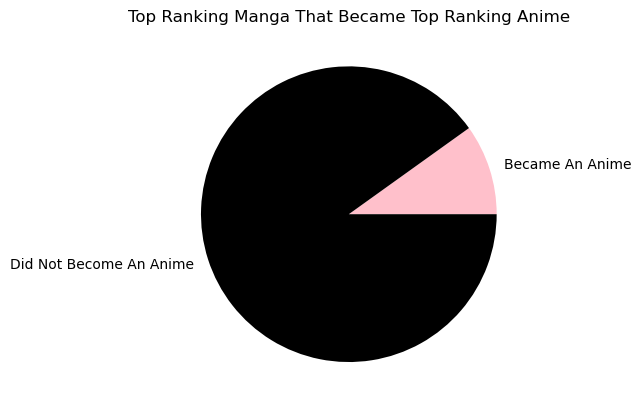

In [28]:
# Your visualization here
result3.count()
b = 495 - result3.count()
values = [49, 446]
labels = ['Became An Anime', 'Did Not Become An Anime']
colors = ['pink','black']
plt.pie(values, labels=labels, colors=colors)
plt.title("Top Ranking Manga That Became Top Ranking Anime")
plt.show()

## Findings

There is some overlap present between the two data sets! Out of 500 anime, 49 of them came from the top 500 manga list. When I read through my results I saw that "Hunter x Hunter" was listed twice, but upon further research I learned that there are two "Hunter x Hunter" anime series both based on the same manga. I am happy to see that there is overlap between my two data sets, but I wish that there had been a bigger area of intersection that I could have more to examine. I'm not  shocked by how small the overlapping area is since it takes time, sometimes 10 or more years, for adaptations of books to be created and these two data sets are only 6 years a part. 

## Question 3.2

There is an overlap between the two data sets. Are there similarities in the popularity, ranking, and/or serialization between the manga that were turned into anime?

In [29]:
# Your analysis here
result4 = pd.read_sql_query("""
    SELECT manga.title_english, manga.Score, manga.Popularity, manga.Ranked, manga.Serialization, manga.Members
    FROM manga 
    INNER JOIN anime3 
    ON manga.title_english = anime3.title_english;
""", con)
result4

,title_english,Score,Popularity,Ranked,Serialization,Members
0,Monster,9.07,39.0,5.0,Big Comic Original,103030.0
1,Berserk,9.33,4.0,1.0,Young Animal,296958.0
2,One Piece,9.08,2.0,4.0,Shounen Jump (Weekly),306944.0
3,Death Note,8.73,8.0,36.0,Shounen Jump (Weekly),247508.0
4,Hunter x Hunter,8.69,17.0,43.0,Shounen Jump (Weekly),148593.0
5,Hunter x Hunter,8.69,17.0,43.0,Shounen Jump (Weekly),148593.0
6,Nana,8.70,106.0,42.0,Cookie,64056.0
7,Ouran High School Host Club,8.55,53.0,93.0,LaLa,94503.0
8,Slam Dunk,8.98,89.0,10.0,Shounen Jump (Weekly),69802.0
9,Cardcaptor Sakura,8.40,162.0,168.0,Nakayoshi,47187.0


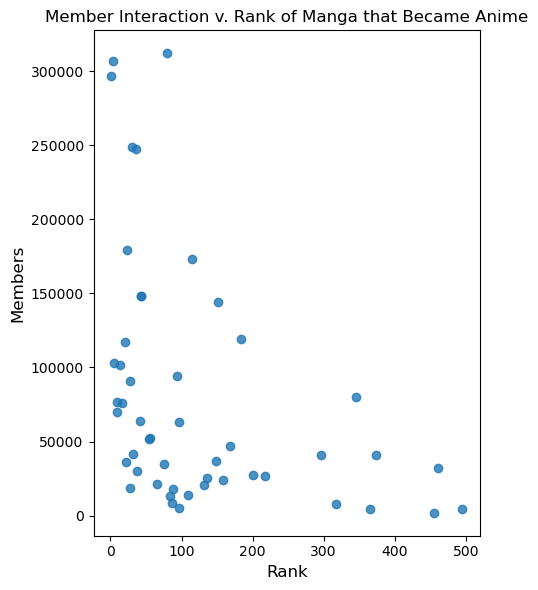

In [30]:
# Your visualization here
plt.figure(figsize=(5,6))
plt.scatter(result4['Ranked'],result4['Members'], alpha=0.8)
plt.xlabel('Rank', fontsize=12)
plt.ylabel('Members', fontsize=12)
plt.title("Member Interaction v. Rank of Manga that Became Anime")
plt.tight_layout()
plt.show()

## Findings

This plot demonstrates that among the manga that became anime, their rank as manga had generally positive relationship with their member interaction. This means that a higher level of member interaction did correlate towards a higher score. This makes sense to me since the scores are decided upon by member votes. This does make me consider the validity of my data set, since fans are likely to be biased towards their favorite medias. I would be curious to compare these ranks with ones not made by fans, such as a ranking of commercial success. 

## Question 3.3

Did manga that became anime receive a relatively similar ranking as when they were only manga? (Comparing between the manga rank and anime rank)

In [31]:
# Your analysis here
con = sqlite3.connect(':memory:')

df2 = pd.read_csv('animeranks.csv')
df2.to_sql('animeranks', con, index=False)

df1 = pd.read_csv('mangadatatrue2.csv')
df1.to_sql('manga', con, index=False) 

result5 = pd.read_sql_query("""
    SELECT manga.title_english, animeranks.title_english, animeranks.Ranked As Anime_Rank, manga.Ranked As Manga_Rank
    FROM manga 
    INNER JOIN animeranks 
    ON manga.title_english = animeranks.title_english;
""", con)
result5

,title_english,title_english,Anime_Rank,Manga_Rank
0,Monster,Monster,25.0,5.0
1,Berserk,Berserk,104.0,1.0
2,One Piece,One Piece,52.0,4.0
3,Death Note,Death Note,97.0,36.0
4,Hunter x Hunter,Hunter x Hunter,9.0,43.0
5,Hunter x Hunter,Hunter x Hunter,204.0,43.0
6,Nana,Nana,119.0,42.0
7,Ouran High School Host Club,Ouran High School Host Club,494.0,93.0
8,Slam Dunk,Slam Dunk,131.0,10.0
9,Cardcaptor Sakura,Cardcaptor Sakura,453.0,168.0


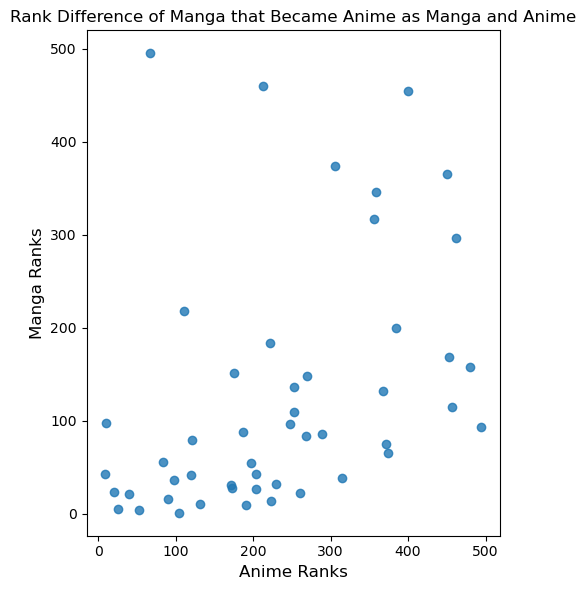

In [32]:
# Your visualization here
plt.figure(figsize=(5,6))
plt.scatter(result5['Anime_Rank'],result5['Manga_Rank'], alpha=0.8)
plt.xlabel('Anime Ranks', fontsize=12)
plt.ylabel('Manga Ranks', fontsize=12)
plt.title("Rank Difference of Manga that Became Anime as Manga and Anime")
plt.tight_layout()
plt.show()

## Findings

This plot demonstrates that while there is some positive relationship between the rank of a text as an anime and the same text as manga, this relationship isn't very strong. This means that a manga that was high ranking and is then turned into an anime doesn't inherently have a high rank as an anime. I think that this could be true for a variety of reasons such as the fact that animation studios sometimes change the original plot of the story to adapt it to be something that is more palatable for a television audience. 

# **Conclusion**

## Summary of Findings

This data analysis process was very informative. My first question addressed who the powerhouses of serialization in the manga industry are. I found that the two most prominent companies were Shounen Jump (Weekly) and Shounen Magazine (Weekly). While other companies were listed, these were the two most prominent by a large margin. In question 1 I also tackled other aspects of what it might mean to be a "powerhouse," such as the issue of quality versus quantity. My second plot in question 1 showed me that the average scores of manga produced by companies in the top 10 for counts of series under their label were very similar, with Young Jump only having a slightly higher average of 8.514. In the third part of question 1 I also looked into the average ranking of the manga produced by all serialization companies against the total number of volumes that the company had produced. This plot was very informative and while it confirmed that Shounen Jump (Weekly) does produce the highest number of volumes of manga, they also lean towards the middle of the pack in terms of average rankings. The plot demonstrated that companies make a trade-off between quality and quantity. The company with the highest average rank, Mephisto, had only 6 volumes of manga.

My second question looked into the average popularity of manga when the manga were sorted into categories based on their publishing status, where the categories were as follows: currently being published (publishing), series has been entirely published (finished), and on-hiatus from publishing (on-hiatus). Analysis showed the manga that are currently being published and released have a higher average popularity than manga corresponding to other publishing statuses. While this was surprising to me initially, since I thought that completed manga would be more popular, this makes sense from a social standpoint. Manga that are currently being released will likely have a more active fan base and the company producing the manga will be working hard to promote the series if they are still relying on sales of the series to have a financial basis to continue the series. Through my analysis of the genre distribution of manga at each production status, I have come to the conclusion that production status is less tied to genre, and is more about the general distribution of the popularity of a manga's genre. For example, the drama genre was one of the top three most common genres across all production statuses. Drama is also the third most common genre overall, so I am not surprised by this. I also would like to address my lack of plot diversity for question 2. In question 2, I was only concerned with the genre and production status, so I while I made an attempt to relay this information with a non-bar chart, I ultimately felt that a bar chart was the best method of relaying this information since I wanted to look strictly at the categorical data of genre and status. I discussed the possibility of making this information into a line chart plotting time along the x-axis, but I feel that since my question doesn't ask about time, I wanted to keep my plots concise. This choice was also influence by my idea that having simpler plots would be easier to explain in a shorter time frame during my presentation.

My third question examined the rate of turnover of top 500 ranking manga becoming top 500 ranking anime. After joining my two datasets (anime and manga), I was able to discern that only 49 of the top 500 ranking manga became top 500 ranking anime. This number did shock me because I thought that a popular book series would surely equate to a popular show, but a key factor that I thought about in trying to rationalize this finding was that these rankings are made by fans. A series that is very popular among fans might not be the most appealing for a variety of reasons to an animation company. Also, some authors might not want to sell their story to a production company. In the second part of question 3 I looked at the member interaction versus rank of manga that went on to become anime. There was a positive relationship between member interaction and rank, meaning that a higher rank correlated to a higher level of member interaction. In the final part of question 3 I examined the ranks of manga that became anime when they were manga and when they became an anime. There was a less strong relationship to be seen here, which makes sense since a lot of changes can be made during the adaptation process that can cause opinions to change.

## Limitations

The most difficult part of dealing with this data was being able to join my two data sets, so I feel that wasn't entirely able to answer my third question as thoroughly as I would've liked. The English titles of the manga might not have corresponded with the English titles of the anime that they may have served as the basis of due to translation errors. The manga data set that I selected to work with did not have a list of the series' names in Japanese, so I wasn't able to work backwards from the Japanese anime names provided to me in my anime data set. If I was able to devote more time to this project, I'd want to find another manga data set that included the Japanese names of the manga listed in the top 500 on MyAnimeList.net. This way, I could align the manga's English titles with their Japanese ones, and then use the Japanese titles as a key to match my manga and anime data sets together. Another area of limitation that I discussed a bit in this project was the fact that I am dealing exclusively with fan based rankings. Fans aren't without their biases, so the ranking data might oppose data about the commercial success of certain manga or anime. If given more time, I would be curious to see how different my results would be if the rankings used were based on data not collected from fans, but instead a less biased source like revenues made from the anime or manga.

## Sources

- Dataset 1: https://www.kaggle.com/datasets/ajpass/top-ranked-mangas-myanimelist-mal
- Dataset 2: https://www.kaggle.com/datasets/muhammadaqeelkabir/top-anime-csv

In [33]:
conn.close()